# Package Usage Example Notebook

## 1. Compute Geometric features

import the class `GeometricFeatureCalculator`

In [ ]:
from point_cloud_classifier.data_handler import GeometricFeatureCalculator

create a new pointcloud with geometric features computed. The following code block runs withh all the per default set features `REQUIRED_FEATURES`, which are defined in `point_cloud_classifier.constants`. Its also possible to compute each feature type individually (3D-features, 2D-features, 1D-feature or Z-features)

In [ ]:
input_pointcloud_path = r".\Essais\inputRawPointCloud\2551000_1204000.copc.laz"
output_pointcloud_path = r".\Essais\OutputRawPointCloud\0_2551000_1204000.laz" # cannot write .copc output

data_handler = GeometricFeatureCalculator(input_pointcloud_path)
data_handler.compute_features() # compute all geometric features per default, the output is in the instance of the class and will be lost if not save to a file
data_handler.write_point_cloud(output_pointcloud_path) # -> saves the pointcloud in .laz format

if an entire directory of tiles needs to be computed, an iteration can be done

In [ ]:
import os

input_directory = r".\Essais\inputRawPointCloud"
output_directory = r".\Essais\outputRawPointCloud"
for file in os.listdir(input_directory):
    if not file.endswith('.laz') or not file.endswith('.las'):
        continue
    data_handler = GeometricFeatureCalculator(os.path.join(input_directory, file)) # will be overwritten at every new iteration to avoid too much memory allocation
    data_handler.compute_features()
    data_handler.write_point_cloud(os.path.join(output_directory, file))


## 2. Classify Point Cloud

In [26]:
import os
import importlib
if os.getcwd().endswith("docs"):
    os.chdir("../")

import logging
logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s", force=True)

import point_cloud_classifier.classifier
importlib.reload(point_cloud_classifier.classifier)
from point_cloud_classifier.classifier import PointCloudClassifier, DataClassifierFormat
importlib.reload(point_cloud_classifier.helper)
from point_cloud_classifier.helper import visualize_point_cloud_classification

point_cloud_path = r"D:\Raphael\Essais\TestPointcloud\10_2551000_1201500_tile8.laz"

classifier = PointCloudClassifier()

# points, X = DataClassifierFormat.load_data(point_cloud_path)
points, X, Y = DataClassifierFormat.load_data(point_cloud_path, return_classification=True, fraction_of_dataset=1) # already classified point cloud to check the quality of the classifier

Loading dataset: 100%|██████████| 1/1 [00:30<00:00, 30.56s/pointcloud]


### 2.0 Classify all classes

In [27]:
all_labels = classifier.predict(X, points)
visualize_point_cloud_classification(points, all_labels, "./visualization/All_classified_campagne.laz") # creates a pointcloud as output where we caan visualize the classified pointcloud

Prediction over patches:   0%|          | 0/1 [00:00<?, ?patch/s]

Prediction over patches: 100%|██████████| 1/1 [00:53<00:00, 53.51s/patch]


In [28]:
np.mean(all_labels[Y!=2] == Y[Y!=2]) * 100

np.float64(93.89927176328442)

### 2.1 Ground Classification

In [ ]:
ground_labels = classifier.classify_ground_points(X) # return 1 if its classified as ground and else 0
classifier.test_binary_classifier(X, Y==2) # outputs the classifier metrics on the tested data
visualize_point_cloud_classification(points, ground_labels * 2, "./visualization/GroundClassified.laz") # creates a pointcloud as output where we caan visualize the classified pointcloud

2026-06-17 14:36:52,358 - INFO - ==================================================
2026-06-17 14:36:52,359 - INFO - Résultats Globaux :
2026-06-17 14:36:52,360 - INFO -  -> Accuracy  : 96.83 %
2026-06-17 14:36:52,361 - INFO -  -> F1-Score  : 0.9517
2026-06-17 14:36:52,362 - INFO -  -> Recall    : 0.9770
2026-06-17 14:36:52,366 - INFO -  -> Precision : 0.9277
2026-06-17 14:36:52,368 - INFO - ==================================================


Get the classifiers feature importance

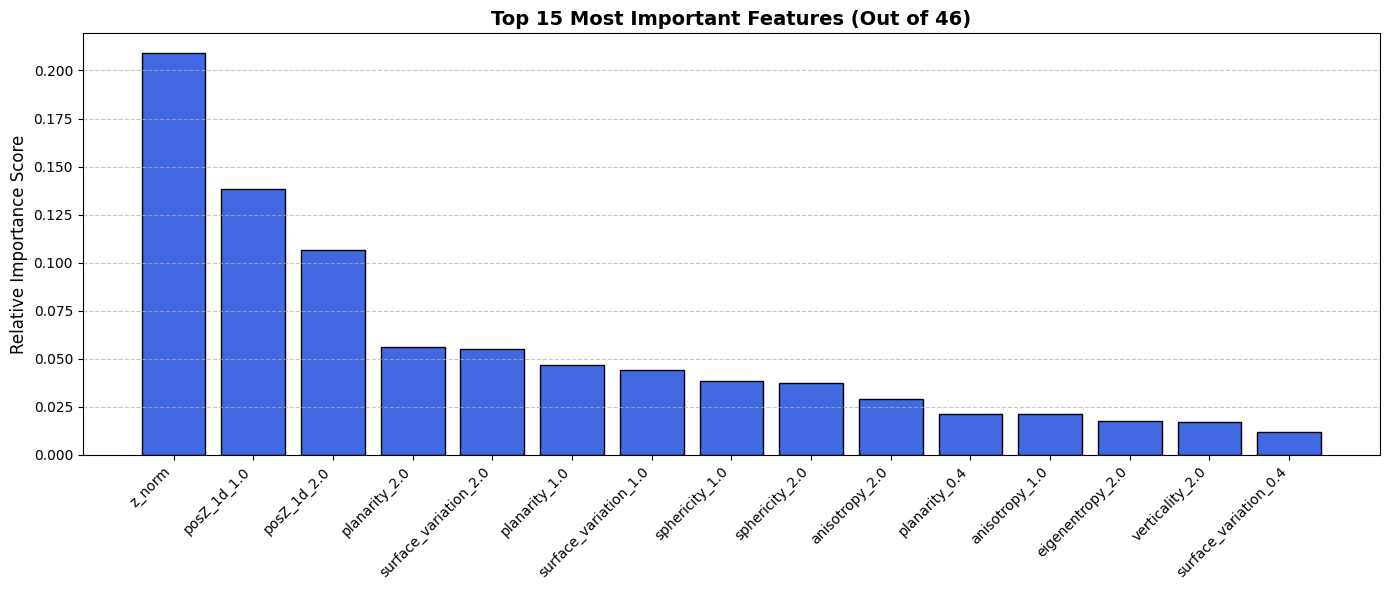

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from point_cloud_classifier.constants import SELECTED_FEATURE_NAMES
importances = classifier.binary_ground_classifier.feature_importances_
indices = np.argsort(importances)[::-1]
top_n = 15
top_indices = indices[:top_n]
plt.figure(figsize=(14, 6))
plt.title(f"Top {top_n} Most Important Features (Out of 46)", fontsize=14, fontweight='bold')
plt.bar(range(top_n), importances[top_indices], color='royalblue', edgecolor='black', align="center")
plt.xticks(range(top_n), [SELECTED_FEATURE_NAMES[i] for i in top_indices], rotation=45, ha='right', fontsize=10)
plt.ylabel("Relative Importance Score", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


### 2.2 (Large) Vegetation Classification

In [ ]:
vegetation_labels = classifier.classify_vegetation_points(points)